# Conformal Mesh Generation from Monte-Carlo Grain Structures: Technique B

This notebook demonstrates the workflow for generating conformal finite element meshes from Monte-Carlo grain growth simulations. The process includes:

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from upxo.pxtal.geometrification import GrainManifold2D
import upxo.gsdataops.grid_ops as gridOps
from upxo.viz import gsviz
from upxo.ggrowth.mcgs import mcgs
from copy import deepcopy
import cc3d

## Step 1: Generate Grain Structure via Monte-Carlo Simulation

Run a Monte-Carlo grain growth simulation to create a synthetic polycrystalline microstructure. The label field image (LFI) stores grain IDs at each pixel location.

In [2]:
pxt = mcgs(input_dashboard = 'C:\\Development\\UPXO\\upxo_library\\src\\upxo\\demos\\confMesh\\confMesh1.xls')
pxt.simulate()
pxt.detect_grains(library='cc3d', connectivity=4)
tslice = list(pxt.gs.keys())[-7]
gstslice = pxt.gs[tslice]

C:\Development\UPXO\upxo_library\src\upxo\interfaces\user_inputs
C:\Development\UPXO\upxo_library\src\upxo\demos\confMesh\confMesh1.xls
Algo_hops details
(('200.0', 100),)
[False]

 Initiating Monte-Carlo simulation
     xmin, xmax, xinc: 0.0, 50.0, 1.0
     ymin, ymax, yinc: 0.0, 50.0, 1.0
     zmin, zmax, zinc: 0.0, 100.0, 1.0
     No. of states: 20
     Dimensionality: 2
Using ALG-200: SA's SL NL-1 TP1 C2 unweighted Q-Pott's model:
|--------------- MC SIM RUN IN PROGRESS on: ALG200---------------|
GS temporal slice 0 stored
GS temporal slice 1 stored
GS temporal slice 2 stored
GS temporal slice 3 stored
GS temporal slice 4 stored
GS temporal slice 5 stored
GS temporal slice 6 stored
GS temporal slice 7 stored
GS temporal slice 8 stored
GS temporal slice 9 stored
|--------------- MC SIM RUN COMPLETED on: ALG200---------------|
Using cc3d for grain identification


In [3]:
lfi = gstslice.lfi

## Step 2: Extract and Visualize Label Field Image

Extract the grain structure as a label field image (LFI), where each pixel value represents the grain ID it belongs to.

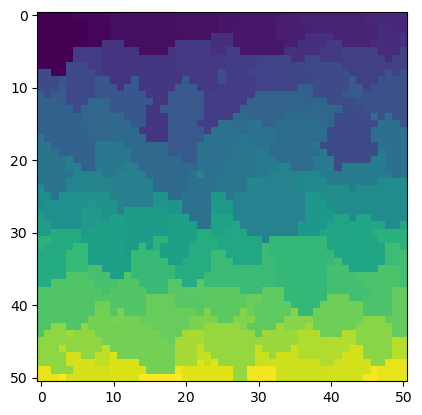

In [4]:
plt.imshow(lfi)

## Step 3: Compute Grain Topology

Find neighboring grains and compute grain areas to prepare for topology cleanup.

In [5]:
from upxo.gsdataops.gid_ops import find_neighs2d
neigh_gid = find_neighs2d(lfi, conn=4)

In [6]:
areas = np.bincount(lfi.ravel())[1:]
areas

array([ 3, 46,  3, 12,  1,  1, 47, 21,  1,  8, 35,  1,  1, 14,  1,  9, 28,
        5,  8,  1, 13,  8, 15,  2, 27, 52, 32,  8, 11, 49, 26,  7, 15, 15,
        8, 23, 73,  9,  2, 32,  2,  1,  8, 23, 49,  6,  4,  1,  2, 50, 25,
        7, 22, 13, 57,  5, 44,  1, 29, 57, 13, 27, 28, 20,  1, 10, 12, 22,
        3, 30, 74,  8,  8,  1, 11,  2, 44,  4, 11, 24,  2,  8,  8,  2, 20,
       10,  6, 33,  5, 38, 25,  8,  9, 41, 25,  1,  1, 30, 27,  1,  1,  8,
        3,  3,  1, 71, 11, 29, 41,  6,  5, 21,  9,  7, 22, 55, 24, 13, 27,
       25, 15, 31,  4, 32,  2, 60,  3,  7,  5,  8, 28, 23, 16, 41, 17,  1,
        1, 13,  3, 22,  6,  6,  1,  5,  4,  5, 25, 21, 17, 14, 10,  6, 11,
        5,  1,  8,  3,  1,  6])

## Step 4: Merge Small Grains

Remove artifacts by merging grains below an area threshold with their largest neighboring grain. This improves mesh quality by eliminating tiny elements.

In [7]:
def merge_small_grains(neigh_gid, areas, lfi, athreshold=1):
    """
    Merge small grains with their dominant (largest) neighboring grain.
    Recomputes connected components and updates neighbor/area data after each merger.
    
    Parameters
    ----------
    neigh_gid : dict
        Dictionary mapping grain IDs to arrays of neighboring grain IDs
    areas : np.ndarray
        Array of grain areas (pixel counts), indexed by grain ID (starting from 1)
    lfi : np.ndarray
        Label field image (2D array of grain IDs)
    athreshold : int
        Area threshold for identifying small grains
    
    Returns
    -------
    lfi_merged : np.ndarray
        Updated label field image with small grains merged
    """
    def find_dominant_neighbor(gid, neigh_gid, areas):
        """Find the dominant (largest area) neighbor for a grain."""
        if gid in neigh_gid and len(neigh_gid[gid]) > 0:
            neighbors = neigh_gid[gid]
            neighbor_areas = areas[neighbors - 1]
            return neighbors[np.argmax(neighbor_areas)]
        return gid
    lfi_merged = deepcopy(lfi)
    # Identify and merge small grains
    small_grains = np.where(areas <= athreshold)[0] + 1
    for gid in small_grains:
        dominant = find_dominant_neighbor(gid, neigh_gid, areas)
        lfi_merged[lfi_merged == gid] = dominant
        lfi_merged = cc3d.connected_components(lfi_merged, connectivity=4)
        # Update neighbor and area data after merger
        neigh_gid = find_neighs2d(lfi_merged, conn=4)
        areas = np.bincount(lfi_merged.ravel())[1:]
    return lfi_merged

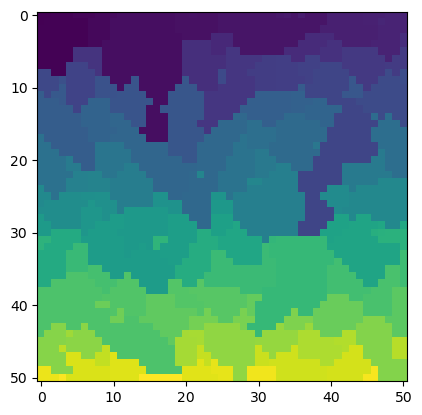

In [8]:
lfi_merged = merge_small_grains(neigh_gid, areas, lfi, athreshold=1)
plt.imshow(lfi_merged)

## Step 5: Generate Voronoi Seeds for Tessellation

Create hybrid seed distribution with dense placement near grain boundaries and coarser spacing in grain interiors. See parameter documentation below.

### Seed Generation Parameters

The `generate_constrained_hybrid_seeds()` function in the next cell creates seed points. The followimgh are the imput parameters.

1. **<span style="color: teal;">target spacing (float, default=1.0)</span>**
> This is the Target distance between seeds at grain boundaries. Smaller values produce denser seeds near grain boundaries, and thus enusuring better resolution at the grain boduanrtu interface. The degfault value is set to pixel size.
2. **<span style="color: teal;">Bulk spacing (float, default=1.0)</span>**
> This is the target distance between seeds at grain interriors, that is atleast 1 pixel away from the grain boudnary. Larger values produce coarser mesh inside grains, and thus ensuring reduced element count and faster computation. DEfaults to 1.0 to ensure error free computation, but this can be much larger, depending on your geometry. So, you need to play around a bit with this number for the grain structrue morphology that you have.
3. **<span style="color: teal;">Jitter factor (float, range [0, 1], default=0.0)</span>**
> This is a random perturbation applied to seed positions. The default is set to 0, which is pretty much good enough, but if you do end yup with some errors, try increasing it slightly by sub-pixel size increments. Use a valyue of `1.0` for maximum randomness (up to ±50% of spacing). Increasing beyond 1.0 would not cghange the randomness but, increases the risk of havingh the bulk seed point distribution falling outside the grain boundary for a given grain, depending on the buffer distabnce value. The effect is not-noticeable because, the interior cells gets merged anyways.
4. **<span style="color: teal;">Margin (float, default=0.0)</span>**
> This is the buffer distance towards the grain interior where GB boundary seeds are placed. It prevents the seeds from sitting exactly on interfaces and ensures numerical stability Positive values mean thst the seeds are placed slightly inside grains byut near to the GB.
5. **<span style="color: teal;">padding (float, default=0.0)</span>**
> This is the distance beyond the domain's bounding box. It is provided to ensure that Voronoi cells fully cover GS domain edges by adding another layer of Voronoi cells at the first ocurance of open cells at the boundary. These safety cells will get trimmed to the original GS bounding box dimensions.
```

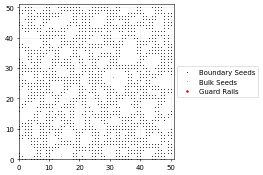

In [9]:
seeds = gridOps.generate_constrained_hybrid_seeds(lfi, target_spacing=1.0, bulk_spacing=1.0, jitter_factor=0.25, margin=0.5, padding=2.0, plot_seeds=True, figsize=(5, 5), dpi=50, markersize=0.5)

## Step 6: Create Grain Manifold via Voronoi Tessellation

Generate a `GrainManifold2D` object by performing Voronoi tessellation using the seed points. This creates polygon cells representing each grain's geometry.

In [10]:
manifold_structure = GrainManifold2D.by_tessellation(lfi, seeds)

In [11]:
original_cells = {gid: geom for gid, geom in manifold_structure.cells.items()}

### Visualize Original Tessellation

Save the original cell geometries before smoothing to compare before/after interface quality.

(<Figure size 1200x600 with 1 Axes>, [<Axes: title={'center': 'Subplot 1'}>])

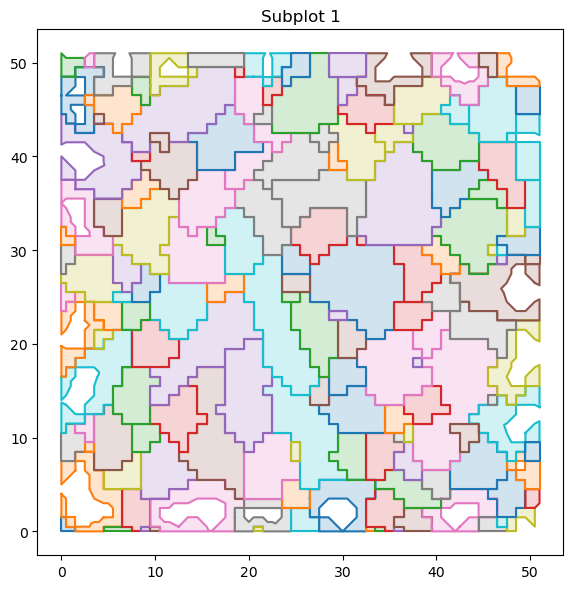

In [12]:
gsviz.plot_manifold_geom([original_cells], figsize=(12, 6), dpi=100, inlude_legend=False)

## Step 7: Smooth Grain Interfaces

Apply smoothing to grain boundaries to reduce jaggedness from pixelated grain structures.

In [13]:
manifold_structure.smooth_interfaces(iterations=10, lmbda=0.5, mu=-0.53)

(<Figure size 1200x600 with 2 Axes>,
 array([<Axes: title={'center': 'Subplot 1'}>,
        <Axes: title={'center': 'Subplot 2'}>], dtype=object))

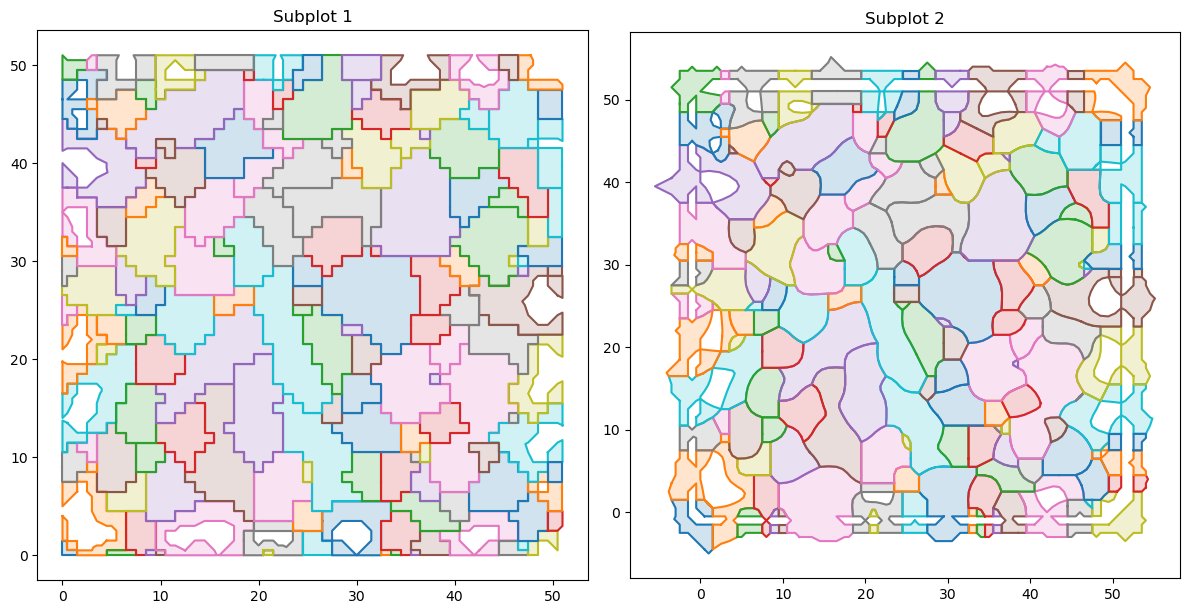

In [14]:
gsviz.plot_manifold_geom([original_cells, manifold_structure.cells], figsize=(12, 6), dpi=100, inlude_legend=False)

## Step 8: Trim the GS

Clip the manifold structure to the desired RVE bounds, removing grains that extend beyond the simulation domain.

In [15]:
_ = manifold_structure.trim_to_rve(bounds=(5, 5, 45, 45))

(<Figure size 2400x1200 with 2 Axes>,
 array([<Axes: title={'center': 'Subplot 1'}>,
        <Axes: title={'center': 'Subplot 2'}>], dtype=object))

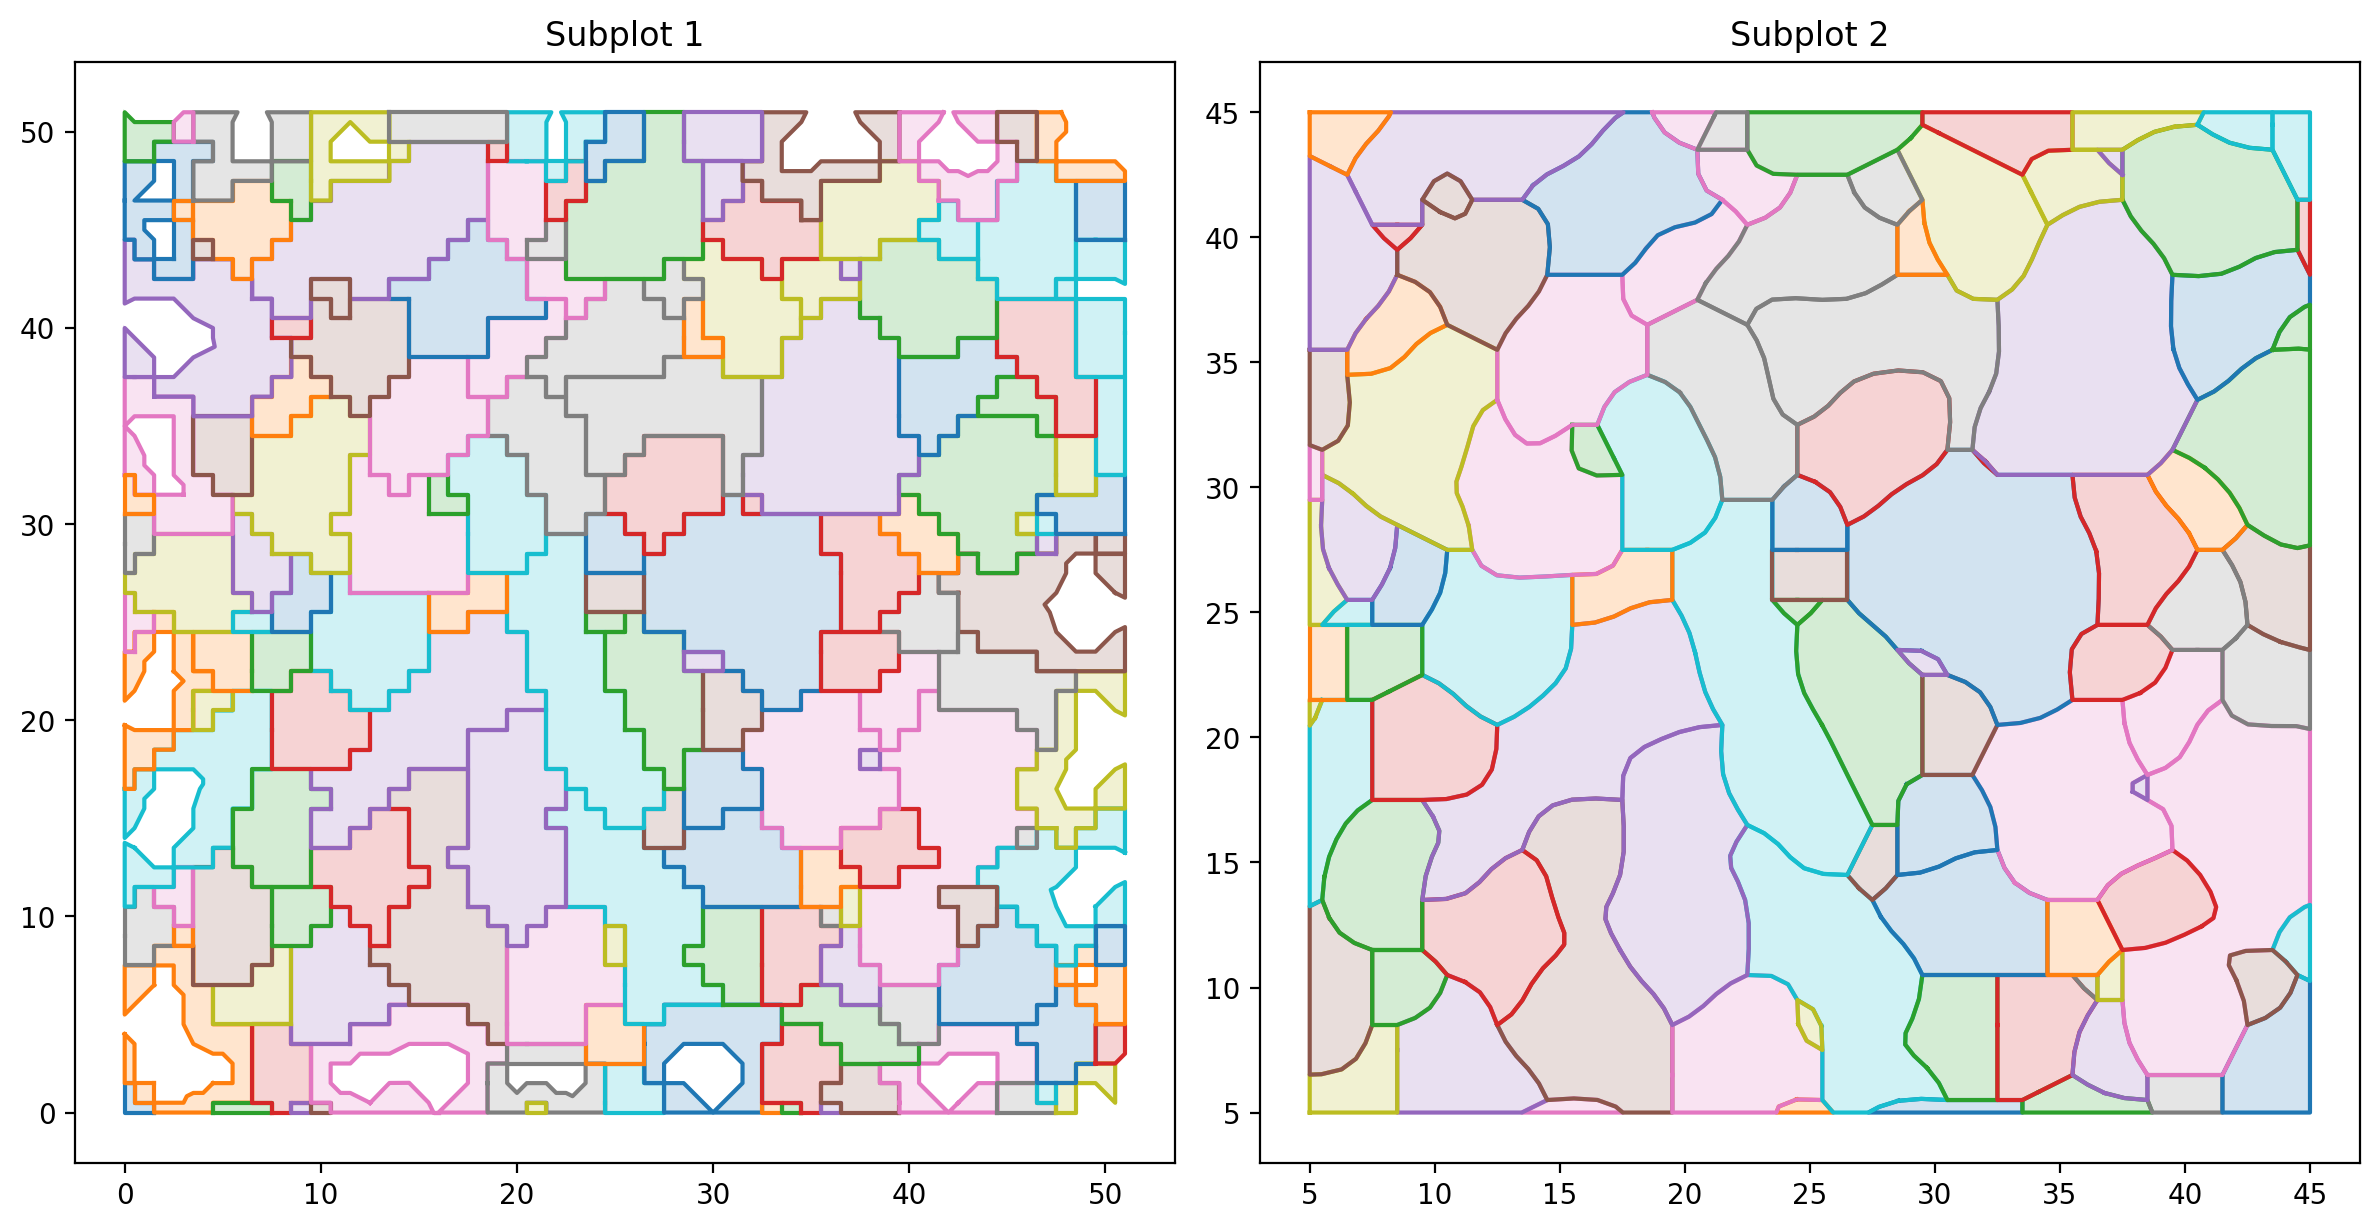

In [16]:
gsviz.plot_manifold_geom([original_cells, manifold_structure.cells], figsize=(12, 6), dpi=200, inlude_legend=False)

# =========================

# DEV

In [17]:
from shapely.geometry import MultiPolygon

## Step 9: Clean Invalid Geometries

Remove polygons with zero area or invalid geometries that may arise from trimming operations.

In [18]:
"""Remove empty/invalid polygons and reconstruct the dictionary"""
cleaned_cells = {}
for gid, geom in manifold_structure.cells.items():
    """Check if geometry is valid and has non-zero area"""
    if geom is not None and geom.is_valid and geom.area > 0:
        cleaned_cells[gid] = geom
"""Update the manifold structure with cleaned cells"""
manifold_structure.cells = cleaned_cells

print(f"Removed {len(manifold_structure.cells) - len(cleaned_cells)} empty/invalid polygons")
print(f"Remaining polygons: {len(cleaned_cells)}")
manifold_structure.cells

Removed 0 empty/invalid polygons
Remaining polygons: 99


{7: <POLYGON ((14.5 5.5, 15.564 5.564, 16.504 5.504, 17.237 5.237, 17.52 5, 13.4...>,
 11: <POLYGON ((28.531 5.469, 29.453 5.547, 30.5 5.5, 31.5 5.5, 32.5 5.5, 33.5 5....>,
 22: <POLYGON ((24.476 5.524, 25.5 5.5, 25.936 5, 23.663 5, 23.758 5.242, 24.476 ...>,
 23: <POLYGON ((34.167 5.833, 34.833 6.167, 35.5 6.5, 36.114 6.114, 36.783 5.783,...>,
 25: <POLYGON ((8.5 7.5, 8.5 8.5, 9.217 8.783, 9.807 9.193, 10.217 9.783, 10.5 10...>,
 26: <POLYGON ((12.5 8.5, 13.067 8.926, 13.504 9.485, 13.873 10.145, 14.325 10.76...>,
 27: <POLYGON ((19.5 6.5, 19.5 7.5, 19.5 8.5, 20.165 8.835, 20.74 9.26, 21.26 9.7...>,
 28: <POLYGON ((38.5 6.5, 39.5 6.5, 40.5 6.5, 41.5 6.5, 41.5 5.5, 41.5 5, 38.697 ...>,
 29: <POLYGON ((5 5, 5 6.516, 5.469 6.531, 6.275 6.725, 6.85 7.15, 7.228 7.772, 7...>,
 30: <POLYGON ((25.462 8.462, 25.129 9.129, 24.5 9.5, 24.129 10.129, 23.462 10.46...>,
 31: <POLYGON ((41.5 6.5, 41.833 7.167, 42.167 7.833, 42.5 8.5, 43.217 8.783, 43....>,
 33: <POLYGON ((29.689 6.782, 29.159 7.279, 

(<Figure size 1800x900 with 1 Axes>, [<Axes: title={'center': 'Subplot 1'}>])

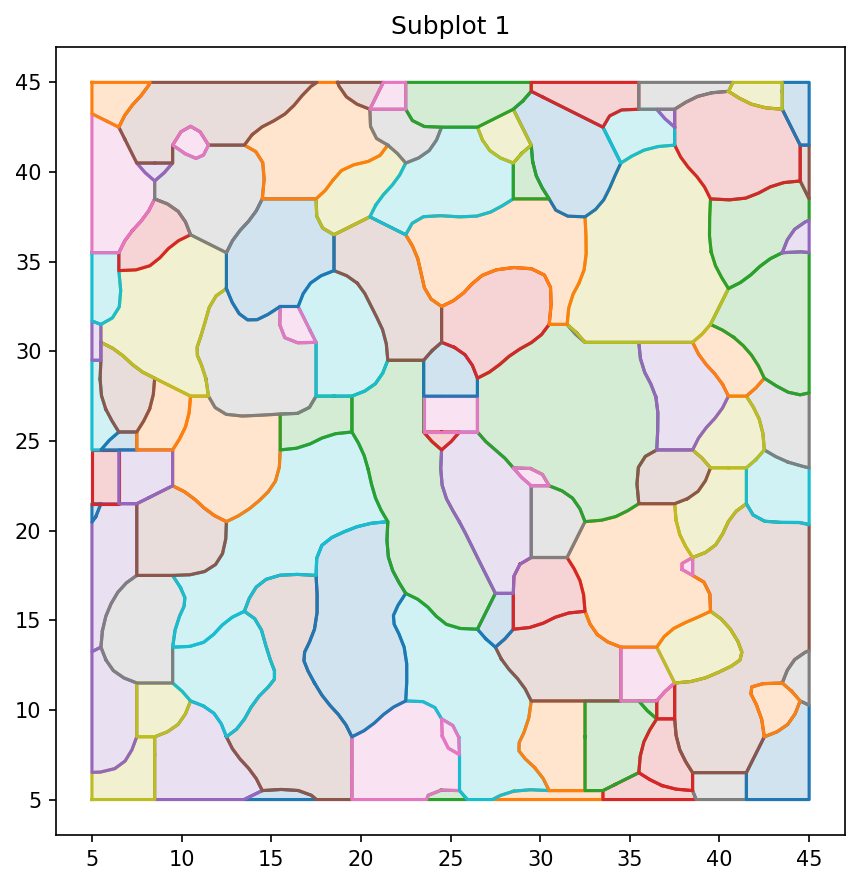

In [19]:
gsviz.plot_manifold_geom([manifold_structure.cells], figsize=(12, 6), dpi=150, inlude_legend=False)

## Step 10: Construct Neighbor Topology

Build a neighbor dictionary mapping each grain ID to all grains it shares a boundary with. This uses Shapely's `touches()` method to detect topological adjacency.

In [20]:
from collections import Counter
"""Construct neighbor dictionary for all polygons with integer GIDs starting from 1"""
polygon_neighbors = {}
"""Get list of GIDs and ensure they're integers in sorted order"""
gids = sorted([int(gid) for gid in manifold_structure.cells.keys()])
"""For each polygon, find all neighbors (polygons that touch it)"""
for gid1 in gids:
    polygon_neighbors[gid1] = []
    geom1 = manifold_structure.cells[gid1]
    """Compare with all other polygons"""
    for gid2 in gids:
        if gid1 != gid2:
            geom2 = manifold_structure.cells[gid2]
            """Check if polygons touch (share boundary but don't overlap)"""
            if geom1.touches(geom2):
                polygon_neighbors[gid1].append(gid2)
# Summary
print(f"Total polygons: {len(polygon_neighbors)}")
print(f"\nNeighbor statistics:")
neighbor_counts = [len(neighs) for neighs in polygon_neighbors.values()]
print(f"  Min neighbors: {min(neighbor_counts)}")
print(f"  Max neighbors: {max(neighbor_counts)}")
print(f"  Avg neighbors: {sum(neighbor_counts) / len(neighbor_counts):.2f}")
# grain_ids, neigh_id = find_neighs()
neigh_dist = Counter(neighbor_counts)
print(f"\nNeighbor count distribution:")
for n_neighs in sorted(neigh_dist.keys()):
    count = neigh_dist[n_neighs]
    print(f"  {n_neighs} neighbors: {count} polygons")

print(f"\nSample neighbors:")
for gid in list(polygon_neighbors.keys())[:5]:
    print(f"  GID {gid}: {polygon_neighbors[gid]}")

Total polygons: 99

Neighbor statistics:
  Min neighbors: 2
  Max neighbors: 12
  Avg neighbors: 5.21

Neighbor count distribution:
  2 neighbors: 7 polygons
  3 neighbors: 14 polygons
  4 neighbors: 19 polygons
  5 neighbors: 23 polygons
  6 neighbors: 15 polygons
  7 neighbors: 6 polygons
  8 neighbors: 8 polygons
  9 neighbors: 2 polygons
  10 neighbors: 2 polygons
  11 neighbors: 1 polygons
  12 neighbors: 2 polygons

Sample neighbors:
  GID 7: [25, 26]
  GID 11: [23, 30, 33, 34]
  GID 22: [27, 30]
  GID 23: [11, 28, 34, 35]
  GID 25: [7, 26, 29, 43, 44]


## Step 11: Normalize Grain IDs

Renumber grain IDs to be contiguous integers starting from 1. This ensures clean indexing for FE export formats.

In [21]:
"""manifold_structure.cells key renumbering to start from 1 contiguously"""
old_to_new_gid = {}
new_cells = {}
"""Debug: Check GIDs in both dictionaries"""
cells_gids = set(manifold_structure.cells.keys())
neighbors_gids = set(polygon_neighbors.keys())
all_neighbor_refs = set()
for neighbors in polygon_neighbors.values():
    all_neighbor_refs.update(neighbors)

print(f"Debug - GIDs in manifold_structure.cells: {len(cells_gids)}")
print(f"Debug - GIDs in polygon_neighbors keys: {len(neighbors_gids)}")
print(f"Debug - All neighbor GID references: {len(all_neighbor_refs)}")

"""Check for mismatches"""
missing_in_cells = all_neighbor_refs - cells_gids
missing_in_neighbors = cells_gids - neighbors_gids
if missing_in_cells:
    print(f"Warning: Neighbor references point to missing cells: {missing_in_cells}")
    print(f"Filtering polygon_neighbors to only include cells in manifold_structure.cells")
    # Filter polygon_neighbors to only include cells that exist
    polygon_neighbors = {gid: neighbors for gid, neighbors in polygon_neighbors.items() if gid in cells_gids}
    
if missing_in_neighbors:
    print(f"Warning: Cells missing from polygon_neighbors: {missing_in_neighbors}")

for new_gid, old_gid in enumerate(sorted(manifold_structure.cells.keys()), start=1):
    old_to_new_gid[old_gid] = new_gid
    new_cells[new_gid] = manifold_structure.cells[old_gid]
manifold_structure.cells = new_cells

"""Update polygon_neighbors with new GID mapping"""
polygon_neighbors_renumbered = {}
for old_gid, neighbors in polygon_neighbors.items():
    new_gid = old_to_new_gid[old_gid]
    new_neighbors = [old_to_new_gid[n] for n in neighbors if n in old_to_new_gid]
    polygon_neighbors_renumbered[new_gid] = new_neighbors
polygon_neighbors = polygon_neighbors_renumbered

print(f"\nRenumbered {len(old_to_new_gid)} grain cells to contiguous IDs from 1 to {len(new_cells)}")
print(f"Sample mapping (old -> new): {dict(list(old_to_new_gid.items())[:5])}")

Debug - GIDs in manifold_structure.cells: 99
Debug - GIDs in polygon_neighbors keys: 99
Debug - All neighbor GID references: 99

Renumbered 99 grain cells to contiguous IDs from 1 to 99
Sample mapping (old -> new): {7: 1, 11: 2, 22: 3, 23: 4, 25: 5}


### Validate Polygon Geometries

Check that all cells in the manifold structure are valid Shapely polygons with non-zero area.

In [22]:
"""Validation check for all polygons in manifold_structure.cells"""
from shapely.geometry import Polygon

validity_report = {}
for gid, geom in manifold_structure.cells.items():
    is_valid = geom.is_valid if geom is not None else False
    is_polygon = isinstance(geom, Polygon) if geom is not None else False
    has_area = geom.area > 0 if geom is not None else False
    validity_report[gid] = {'is_valid': is_valid, 'has_area': has_area, 'is_polygon': is_polygon, 'area': geom.area if geom is not None else 0}

"""Summary"""
print(f"Total polygons: {len(validity_report)}")
valid_count = sum(1 for v in validity_report.values() if v['is_valid'])
area_count = sum(1 for v in validity_report.values() if v['has_area'])
polygon_count = sum(1 for v in validity_report.values() if v['is_polygon'])

print(f"Valid polygons: {valid_count}")
print(f"Polygons with area: {area_count}")
print(f"Polygon type objects: {polygon_count}")

print(f"\nInvalid polygons:")
invalid_polys = {gid: v for gid, v in validity_report.items() if not v['is_valid']}
if invalid_polys:
    for gid, vals in invalid_polys.items():
        print(f"  GID {gid}: {vals}")
else:
    print("  None - all polygons are valid!")

Total polygons: 99
Valid polygons: 99
Polygons with area: 99
Polygon type objects: 99

Invalid polygons:
  None - all polygons are valid!


### Rebuild Neighbor Dictionary (Integer Keys)

Re-construct the neighbor topology with integer keys to ensure consistency after renumbering.

In [23]:
"""Ensure manifold_structure.cells has integer keys starting from 1"""
cells_int = {int(gid) if isinstance(gid, str) else gid: geom 
             for gid, geom in manifold_structure.cells.items()}
manifold_structure.cells = cells_int
"""Construct neighbor dictionary for all polygons with integer GIDs starting from 1"""
polygon_neighbors = {}
"""Get list of GIDs and ensure they're integers in sorted order"""
gids = sorted([int(gid) for gid in manifold_structure.cells.keys()])
"""For each polygon, find all neighbors (polygons that touch it)"""
for gid1 in gids:
    polygon_neighbors[gid1] = []
    geom1 = manifold_structure.cells[gid1]
    """Compare with all other polygons"""
    for gid2 in gids:
        if gid1 != gid2:
            geom2 = manifold_structure.cells[gid2]
            """Check if polygons touch (share boundary but don't overlap)"""
            if geom1.touches(geom2):
                polygon_neighbors[gid1].append(gid2)

print(f"Total polygons: {len(polygon_neighbors)}")
print(f"\nNeighbor statistics:")
neighbor_counts = [len(neighs) for neighs in polygon_neighbors.values()]
print(f"  Min neighbors: {min(neighbor_counts)}")
print(f"  Max neighbors: {max(neighbor_counts)}")
print(f"  Avg neighbors: {sum(neighbor_counts) / len(neighbor_counts):.2f}")

"""Show polygons by neighbor count"""
from collections import Counter
neigh_dist = Counter(neighbor_counts)
print(f"\nNeighbor count distribution:")
for n_neighs in sorted(neigh_dist.keys()):
    count = neigh_dist[n_neighs]
    print(f"  {n_neighs} neighbors: {count} polygons")

print(f"\nSample neighbors:")
for gid in list(polygon_neighbors.keys())[:5]:
    print(f"  GID {gid}: {polygon_neighbors[gid]}")

Total polygons: 99

Neighbor statistics:
  Min neighbors: 2
  Max neighbors: 12
  Avg neighbors: 5.21

Neighbor count distribution:
  2 neighbors: 7 polygons
  3 neighbors: 14 polygons
  4 neighbors: 19 polygons
  5 neighbors: 23 polygons
  6 neighbors: 15 polygons
  7 neighbors: 6 polygons
  8 neighbors: 8 polygons
  9 neighbors: 2 polygons
  10 neighbors: 2 polygons
  11 neighbors: 1 polygons
  12 neighbors: 2 polygons

Sample neighbors:
  GID 1: [5, 6]
  GID 2: [4, 10, 12, 13]
  GID 3: [7, 10]
  GID 4: [2, 8, 13, 14]
  GID 5: [1, 6, 9, 19, 20]


In [24]:
polygon_neighbors

{1: [5, 6],
 2: [4, 10, 12, 13],
 3: [7, 10],
 4: [2, 8, 13, 14],
 5: [1, 6, 9, 19, 20],
 6: [1, 5, 7, 20, 21, 30],
 7: [3, 6, 10, 17, 21],
 8: [4, 11, 14, 16],
 9: [5, 15, 19],
 10: [2, 3, 7, 12, 17, 21, 26, 31, 33],
 11: [8, 16, 18, 22],
 12: [2, 10, 13, 26],
 13: [2, 4, 12, 14, 23, 24, 26, 27],
 14: [4, 8, 13, 16, 23, 24],
 15: [9, 19, 25, 28],
 16: [8, 11, 14, 18, 22, 24, 27, 29, 32, 37, 39, 40],
 17: [7, 10],
 18: [11, 16, 22],
 19: [5, 9, 15, 20, 28],
 20: [5, 6, 19, 28, 30],
 21: [6, 7, 10, 30, 33],
 22: [11, 16, 18],
 23: [13, 14, 24, 27],
 24: [13, 14, 16, 23, 27, 29],
 25: [15, 28, 36, 41, 44, 45],
 26: [10, 12, 13, 27, 31, 32, 34],
 27: [13, 16, 23, 24, 26, 29, 32],
 28: [15, 19, 20, 25, 30, 36],
 29: [16, 24, 27, 32],
 30: [6, 20, 21, 28, 33, 36, 42, 53],
 31: [10, 26, 33, 34, 35],
 32: [16, 26, 27, 29, 34, 37, 38, 39, 43, 46],
 33: [10, 21, 30, 31, 35, 53, 54, 57, 60, 61, 66],
 34: [26, 31, 32, 35, 38],
 35: [31, 33, 34, 38, 43, 47, 54, 57],
 36: [25, 28, 30, 42, 45],
 37:

## Step 12: Create Symmetric Grain-to-Grain Pairs

Convert neighbor dictionary to a set of unique grain interaction pairs `(gid1, gid2)` where `gid1 < gid2`. Each pair represents a grain boundary interface.

In [25]:
"""Construct grain-to-grain interaction pairs (symmetric)"""
cell_pairs = set()
for gid1, neighbors in polygon_neighbors.items():
    for gid2 in neighbors:
        """Create symmetric pairs by always putting smaller ID first"""
        pair = tuple(sorted([gid1, gid2]))
        cell_pairs.add(pair)
"""Convert to sorted list for easier inspection"""
cell_pairs_list = sorted(list(cell_pairs))

print(f"Total cell interaction pairs: {len(cell_pairs_list)}")
print(f"\nFirst 20 pairs:")
for pair in cell_pairs_list[:20]:
    print(f"  {pair}")

print(f"\nSample statistics:")
print(f"  Min cell ID in pairs: {min(min(p) for p in cell_pairs_list)}")
print(f"  Max cell ID in pairs: {max(max(p) for p in cell_pairs_list)}")

Total cell interaction pairs: 258

First 20 pairs:
  (1, 5)
  (1, 6)
  (2, 4)
  (2, 10)
  (2, 12)
  (2, 13)
  (3, 7)
  (3, 10)
  (4, 8)
  (4, 13)
  (4, 14)
  (5, 6)
  (5, 9)
  (5, 19)
  (5, 20)
  (6, 7)
  (6, 20)
  (6, 21)
  (6, 30)
  (7, 10)

Sample statistics:
  Min cell ID in pairs: 1
  Max cell ID in pairs: 99


## Step 13: Extract Grain Boundary Interfaces

For each grain pair, compute the shared interface geometry as a LineString or MultiLineString. This represents the physical grain boundary between two grains.

In [26]:
from shapely.geometry import MultiLineString

"""Create a dictionary mapping each cell pair to its shared interface (MultiLineString)"""
cell_pair_interfaces = {}

for pair in cell_pairs_list:
    gid1, gid2 = pair
    geom1 = manifold_structure.cells[gid1]
    geom2 = manifold_structure.cells[gid2]
    """Get the intersection of the two polygon boundaries.
    This gives us the shared interface as a LineString or MultiLineString"""
    interface = geom1.boundary.intersection(geom2.boundary)
    cell_pair_interfaces[pair] = interface

print(f"Total interfaces extracted: {len(cell_pair_interfaces)}")

"""Categorize interfaces by geometry type"""
interface_types = {}
print(f"\nSample interfaces (first 10 pairs):")
for i, (pair, interface) in enumerate(list(cell_pair_interfaces.items())[:10]):
    geom_type = interface.geom_type
    print(f"  Pair {pair}: {geom_type} (length: {interface.length:.3f})")
    interface_types[geom_type] = interface_types.get(geom_type, 0) + 1  # Count by type

"""Full count across all interfaces"""
for pair, interface in cell_pair_interfaces.items():
    geom_type = interface.geom_type
    interface_types[geom_type] = interface_types.get(geom_type, 0) + 1

print(f"\nInterface geometry type summary:")
for geom_type, count in sorted(interface_types.items()):
    print(f"  {geom_type}: {count}")


Total interfaces extracted: 258

Sample interfaces (first 10 pairs):
  Pair (1, 5): MultiLineString (length: 1.130)
  Pair (1, 6): MultiLineString (length: 3.157)
  Pair (2, 4): LineString (length: 0.500)
  Pair (2, 10): MultiLineString (length: 3.256)
  Pair (2, 12): MultiLineString (length: 2.000)
  Pair (2, 13): LineString (length: 1.000)
  Pair (3, 7): MultiLineString (length: 2.056)
  Pair (3, 10): LineString (length: 0.663)
  Pair (4, 8): LineString (length: 0.537)
  Pair (4, 13): MultiLineString (length: 2.236)

Interface geometry type summary:
  GeometryCollection: 2
  LineString: 46
  MultiLineString: 212
  Point: 8


## Step 14: Detect Triple Junction Points

Identify vertices where three or more grains meet (junction points or JPs). These are critical topological features for mesh conformality and grain boundary network analysis.

**Output:**
- `junction_points`: List of Shapely Point objects at junction coordinates
- `jp_dict`: Dictionary mapping JP ID → [order, (participating grain IDs)]

In [27]:
from collections import defaultdict
from shapely.geometry import Point, Polygon, MultiPolygon

"""Tolerance for grouping nearly-identical coordinates after smoothing"""
coord_decimals = 6
vertex_to_gids = defaultdict(set)

for gid, geom in manifold_structure.cells.items():
    if geom is None or geom.is_empty:
        continue
    polys = [geom] if isinstance(geom, Polygon) else list(geom.geoms) if isinstance(geom, MultiPolygon) else []
    for poly in polys:
        # Exterior ring
        for x, y in list(poly.exterior.coords)[:-1]:  # skip duplicate closing vertex
            key = (round(float(x), coord_decimals), round(float(y), coord_decimals))
            vertex_to_gids[key].add(int(gid))
        # Interior rings (if any)
        for ring in poly.interiors:
            for x, y in list(ring.coords)[:-1]:
                key = (round(float(x), coord_decimals), round(float(y), coord_decimals))
                vertex_to_gids[key].add(int(gid))

"""Keep only true junctions (>=3 grains meeting)"""
junction_items = sorted([(coord, tuple(sorted(gids))) for coord, gids in vertex_to_gids.items() if len(gids) >= 3], key=lambda t: (t[0][0], t[0][1]) )

"""Required list of shapely Point objects"""
junction_points = [Point(x, y) for (x, y), _ in junction_items]

"""JP dictionary: key = JP ID (1-based), value = [order, participating grain IDs tuple]"""
jp_dict = {jp_id: [len(gids), gids] for jp_id, (_, gids) in enumerate(junction_items, start=1)}

print(f"Total junction points: {len(junction_points)}")
print("Sample jp_dict entries:", dict(list(jp_dict.items())[:5]))

Total junction points: 154
Sample jp_dict entries: {1: [3, (15, 25, 28)], 2: [3, (25, 41, 44)], 3: [3, (44, 50, 51)], 4: [3, (50, 56, 65)], 5: [3, (56, 59, 65)]}
